# Import libraries

In [1]:

import numpy as np
import pandas as pd
from pyscf import gto, scf, dft, tools, cc, lo, ao2mo
import ipywidgets as widgets
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, rdCoordGen, rdDetermineBonds
from rdkit.Geometry import Point3D
from rdkit.Chem.Draw import IPythonConsole, MolToImage
import py3Dmol
import cube_tools
import matplotlib.pyplot as plt
from IPython.display import Markdown, display, clear_output
import sys

# Calculations

## Set up molecule


In [2]:
# --- Step 1: widget for XYZ input ---
xyz_input = widgets.Textarea(
    value="2\nhydrogen dimer\nH 0.0 0.0 0.0\nH 0.0 0.0 0.7408",
    description="XYZ Input:",
    layout=widgets.Layout(width="700px", height="200px"),
    style={'description_width':'initial'}
)

output = widgets.Output()

# --- Step 2: function to render molecule ---
def render_molecule(_):
    global mol, xyz_geom
    with output:
        clear_output()
        xyz_string = xyz_input.value
        
        raw_mol = Chem.MolFromXYZBlock(xyz_string)
        mol = Chem.Mol(raw_mol)
        rdDetermineBonds.DetermineConnectivity(mol)
        
        # format structure into readable xyz coordinates
        xyz_geom = []
        for lines in Chem.MolToXYZBlock(mol).split("\n")[2:]:
            strip = lines.strip()
            if strip:
                xyz_geom.append(strip)
        xyz_geom = "\n".join(xyz_geom)

        # print.xyz coordinates of structure
        print('\n XYZ coordinates (\u00C5): \n')
        print(xyz_geom)
        
        view = py3Dmol.view(
            data=Chem.MolToMolBlock(mol),
            style={"stick": {}, "sphere": {"scale": 0.3}},
            width=400,
            height=300,
        )
        view.zoomTo()
        view.show()

# --- Step 3: button to trigger rendering ---
build_button = widgets.Button(description="Render Molecule")
build_button.on_click(render_molecule)

# --- Step 4: layout ---
display(widgets.VBox([xyz_input, build_button, output]))


## SCF calculations

In [3]:
### scf widgets configure ###
basis_options = [('STO-3G', 1), ('3-21G', 2), ('6-31G', 3), ('6-31+G*', 4),
                 ('Other basis', 5)]
basis_dropdown = widgets.Dropdown(description='Basis set: ', options=basis_options,
                                  layout=widgets.Layout(width='auto'), style={'description_width': 'initial'})
custom_basis_input = widgets.Text(value='ccpvtz',
                                   description='Custom basis: ', style={'description_width': 'initial'},
                                   layout = widgets.Layout(width='240px'),
                                   disabled=True)

spin_input = widgets.IntText(
    value=0,
    description='Spin:',
    layout = widgets.Layout(width='150px'),
    style={'description_width': 'initial'},
    disabled=False
)

def on_dropdown_change(change):
    # Display or hide custom basis input based on dropdown selection
    if change['new'] == 5:
        custom_basis_input.disabled = False
    else:
        custom_basis_input.disabled = True
# Add observer to handle dropdown value changes
basis_dropdown.observe(on_dropdown_change, names='value')

def run_calculation(basis_num, custom_basis, method, spin_input, xyz_struc=xyz_geom):
    '''
    Performs a HF or DFT single-point calculation on a molecule.
    Energy results are displayed in a Markdown table.
    Args:
      xyz_struc : str Cortesian coordinates
      basis_num : int index in basis dropdown
      custom_basis : str custom basis input
    '''
    global basis_sets
    basis1       = 'sto3g', 'STO-3G'
    basis2       = '321g', '3-21G'
    basis3       = '631g', '6-31G'
    basis4       = '631+g*', '6-31+G*'
    custom       = custom_basis, 'Custom Basis'

    # list of tuples of pyscf basis definition and name
    basis_sets = [basis1, basis2, basis3, basis4, custom]
    basis = basis_sets[basis_num-1][0] # user-selected basis from the list

    global mf, mol_quantum
    # create pyscf object from input structure
    mol_quantum = gto.M(atom=xyz_struc, basis=basis, unit="ANG", spin=spin_input)
    mol_quantum.build()
    if method == 'hf':
        print(f"\n HF is running \u231B ...")
        mf = scf.RHF(mol_quantum).run(verbose=4)
        mf.dump_scf_summary()
    elif method == 'dft':
        print(f"\n DFT-b3lyp is running \u231B ...")
        mf = dft.RKS(mol_quantum)
        mf.xc = 'b3lyp'
        mf.run(verbose=4)
        mf.dump_scf_summary()
    elif method == 'cc':
        print(f"\n CC is running \u231B ...")
        mf = scf.RHF(mol_quantum).run(verbose=4)
        mycc = cc.CCSD(mf).run(verbose=4)
        mf.dump_scf_summary()

    print("\n \033[1m SCF finished! \033[0m \n")

    mos        = mf.mo_coeff
    elec_ener  = mf.energy_elec()[0] # electronic energy
    nuc_ener   = mf.energy_nuc()     # nuclear     "
    total_ener = mf.energy_tot()     # total       "
    elec_ener_ev  = elec_ener*27.2114
    nuc_ener_ev   = nuc_ener*27.2114
    total_ener_ev = total_ener*27.2114
    corr_ener, corr_ener_ev = 0.0, 0.0
    if method == 'cc':
      corr_ener = mycc.e_corr
      corr_ener_ev = mycc.e_corr*27.2114
      total_ener_ev = total_ener_ev + corr_ener_ev
      total_ener = total_ener + mycc.e_corr

### electronic button configure ###
properties_button = widgets.Button(description='Properties',
                                   layout=widgets.Layout(width='auto'))
properties_button.style.font_weight = 'bold'

def elec_properties(b):
  '''
  Prints dipole moment and Mulliken charges from HF calculation result.
  Args:
    b : Button click.
  '''
  mf.dip_moment(verbose=3)
  print("\n===============================")
  mf.mulliken_pop(verbose=3)
  print(" ")
  for atom in mol.GetAtoms():
    atom.SetProp('molAtomMapNumber', str(atom.GetIdx()+1))
  display(mol)
  properties_button.disabled = True

properties_button.on_click(elec_properties) # link button + function

### scf button configure ###
scf_button = widgets.Button(description='HF-SCF',layout=widgets.Layout(width='auto'))
scf_button.style.font_weight = 'bold'

### dft button configure ###
dft_button = widgets.Button(description='DFT-SCF',layout=widgets.Layout(width='auto'))
dft_button.style.font_weight = 'bold'

### cc button configure ###
cc_button = widgets.Button(description='CC-SCF',layout=widgets.Layout(width='auto'))
cc_button.style.font_weight = 'bold'

def click_scf(b):
  '''Runs the HF calculation.
  Args:
    b : button click.
  '''
  global calc_method
  calc_method = 'HF'
  run_calculation(basis_dropdown.value, custom_basis_input.value, 'hf', spin_input.value, xyz_geom)
  display(Markdown('---'))
  display(properties_button)
  display(Markdown('<br>'))
  scf_button.disabled = True
  basis_dropdown.disabled = True
  custom_basis_input.disabled = True
  dft_button.disabled = True
  properties_button.disabled = False

scf_button.on_click(click_scf) # link button + function

def click_dft(b):
  '''Runs the DFT calculation.
  Args:
    b : button click.
  '''
  global calc_method
  calc_method = 'DFT'
  run_calculation(basis_dropdown.value, custom_basis_input.value, 'dft', spin_input.value, xyz_geom)
  display(Markdown('---'))
  display(properties_button)
  display(Markdown('<br>'))
  scf_button.disabled = True
  basis_dropdown.disabled = True
  custom_basis_input.disabled = True
  dft_button.disabled = True
  properties_button.disabled = False

dft_button.on_click(click_dft) # link button + function

def click_cc(b):
  '''Runs the DFT calculation.
  Args:
    b : button click.
  '''
  global calc_method
  calc_method = 'CC'
  run_calculation(basis_dropdown.value, custom_basis_input.value, 'cc', spin_input.value, xyz_geom)
  display(Markdown('---'))
  display(properties_button)
  display(Markdown('<br>'))
  scf_button.disabled = True
  basis_dropdown.disabled = True
  custom_basis_input.disabled = True
  dft_button.disabled = True
  properties_button.disabled = False

cc_button.on_click(click_cc) # link button + function

### setting up the display ###
top_panel = widgets.HBox([basis_dropdown, scf_button, dft_button, cc_button])
bottom_panel = widgets.HBox([custom_basis_input, spin_input])
panel = widgets.VBox([top_panel, bottom_panel])
display(panel)
basis_link = "[All basis sets](https://pyscf.org/_modules/pyscf/gto/basis.html)"
print(basis_link)

[All basis sets](https://pyscf.org/_modules/pyscf/gto/basis.html)


<br>

In [14]:
#!/usr/bin/env python
#
# Author: Paul J. Robinson <pjrobinson@ucla.edu>
#

# '''
# IBO generation, cube generation, and population analysis
# '''

# from pyscf import lo
# from functools import reduce

# mo_occ = mf.mo_coeff[:,mf.mo_occ>0]
# a = lo.iao.iao(mol_quantum, mo_occ)

# # Orthogonalize IAO
# a = lo.vec_lowdin(a, mf.get_ovlp())

# print(mf.mo_coeff)
# print(a)

# #
# # Method 1, using Knizia's alogrithm to localize IAO orbitals
# #
# '''
# Generate IBOS from orthogonal IAOs
# '''

# ibo = lo.ibo.ibo(mol_quantum, mo_occ, iaos=a)
# print(ibo)

# '''
# Print the IBOS into Gausian Cube files
# '''

# for i in range(ibo.shape[1]):
#     tools.cubegen.orbital(mol_quantum, f'{molecule_name}_ibo1_{i+1:02d}.cube'.format(i+1), ibo[:,i])

# Get and print AO labels and atom-to-AO mapping
# ao_labels = mol_quantum.ao_labels()
# print("AO labels:")
# for i, label in enumerate(ao_labels):
#     print(f"  {i}: {label}")

# AO offsets for each atom. Return a list, each item of the list gives (start-shell-id, stop-shell-id, start-AO-id, stop-AO-id)
atom_to_ao_map = mol_quantum.aoslice_by_atom()
for i, (startshellid, stopshellid, startAOid, stopAOid) in enumerate(atom_to_ao_map):
     atom_symbol = mol_quantum.atom_symbol(i)
     print(f"  Atom {i} ({atom_symbol}): AO indices from {startAOid} to {stopAOid-1}")

# Get NAOs
C_nao = lo.orth_ao(mf, 'nao')
#print(C_nao)


  Atom 0 (O): AO indices from 0 to 8
  Atom 1 (H): AO indices from 9 to 10
  Atom 2 (H): AO indices from 11 to 12
  Atom 3 (O): AO indices from 13 to 21
  Atom 4 (H): AO indices from 22 to 23
  Atom 5 (H): AO indices from 24 to 25


In [15]:
def parse_range(spec: str):
    """
    Parse a string like '1-3,5,7-9' into a list of integers [1,2,3,5,7,8,9].
    """
    numbers = []
    for part in spec.split(','):
        part = part.strip()
        if '-' in part:
            start, end = part.split('-')
            numbers.extend(range(int(start), int(end) +1))
        else:
            numbers.append(int(part))
    return numbers


# User specifies occupied and virtual ranges
fragment_1_spec = "0-12"
fragment_2_spec = "13-25"

fragment_1_orbitals = parse_range(fragment_1_spec)
fragment_2_orbitals = parse_range(fragment_2_spec)

fragments_tstb = [fragment_1_orbitals, fragment_2_orbitals]

print("Orbitals cutoff: \n", fragments_tstb)

Orbitals cutoff: 
 [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]]


In [16]:
# Customize hamiltonian
hcore_nao = np.einsum('pi,pq,qj->ij', C_nao, mf.get_hcore(), C_nao)
#print('H_core in NAO: \n', hcore_nao)
overlap_nao = np.einsum('pi,pq,qj->ij', C_nao, mf.get_ovlp(), C_nao)
#print('Overlap in NAO: \n', overlap_nao)
eri_nao = ao2mo.full(mf._eri, C_nao)
#print('ERI in NAO: \n', eri_nao)

# calculate same molecule in NAO basis for check

mf_nao = scf.RHF(mol_quantum)
mf_nao.get_hcore = lambda *args: hcore_nao
mf_nao.get_ovlp = lambda *args: overlap_nao
mf_nao._eri = ao2mo.restore(8, eri_nao, len(C_nao)) # 8-fold symmetry
mf_nao.init_guess = '1e'
mf_nao.run()

mf_nao.dump_scf_summary()

ref_e_tot = mf_nao.e_tot

: 

In [12]:
def eri_index(p, q, r, s):
    # enforce ordering
    if p < q:
        p, q = q, p
    if r < s:
        r, s = s, r

    pq = p*(p+1)//2 + q
    rs = r*(r+1)//2 + s
    if pq < rs:
        pq, rs = rs, pq

    return pq*(pq+1)//2 + rs


def tstb_get_veff(self, mol, dm, dm_last=None, vhf_last=None, hermi=1, vhfopt=None):
    '''Hartree-Fock potential matrix for the given density matrix
    Args:
        mol : an instance of :class:`Mole`
        dm : ndarray or list of ndarrays
            A density matrix or a list of density matrices
    Kwargs:
        dm_last : ndarray or a list of ndarrays or 0
            The density matrix baseline.  If not 0, this function computes the
            increment of HF potential w.r.t. the reference HF potential matrix.
        vhf_last : ndarray or a list of ndarrays or 0
            The reference HF potential matrix.
        hermi : int
            Whether J, K matrix is hermitian

            | 0 : no hermitian or symmetric
            | 1 : hermitian
            | 2 : anti-hermitian
        vhfopt :
            A class which holds precomputed quantities to optimize the
            computation of J, K matrices
    Returns:
        TS/TB-corrected(!) matrix Vhf = 2*J - K.  Vhf can be a list matrices, corresponding to the
        input density matrices.
    '''
    if dm_last is None:
        vj, vk = self.get_jk(mol, np.asarray(dm))
        print(vj, vk)
        vj, vk = correct_veff(mol, vj, vk, dm)
        print(vj, vk)
        return vj - vk * .5
    else:
        ddm = np.asarray(dm) - np.asarray(dm_last)
        vj, vk = self.get_jk(mol, ddm)
        vj, vk = correct_veff(mol, vj, vk, ddm)
        return vj - vk * .5 + np.asarray(vhf_last)

def correct_veff(mol, vj, vk, dm):
    nao = mol.nao_nr()
    # Zero out ERI contribution
    for p in range(nao):
        for q in range(nao):
            if (p in fragments_tstb[0] and q in fragments_tstb[1]) or \
               (q in fragments_tstb[0] and p in fragments_tstb[1]):
                for r in range(nao):
                    for s in range(nao):
                        # Coulomb term
                        idx = eri_index(p, q, r, s)
                        vj[p, q] -= dm[r, s] * eri[idx]
                        # Exchange term
                        idx_ex = eri_index(p, r, q, s)
                        vk[p, q] -= dm[r, s] * eri[idx_ex]
            else:
                for r in range(nao):
                      for s in range(nao):
                          if (r in fragments_tstb[0] and s in fragments_tstb[1]) or \
                             (s in fragments_tstb[0] and r in fragments_tstb[1]):
                            # Coulomb term
                            idx = eri_index(p, q, r, s)
                            vj[p, q] -= dm[r, s] * eri[idx]
                            # Exchange term
                            idx_ex = eri_index(p, r, q, s)
                            vk[p, q] -= dm[r, s] * eri[idx_ex]
    return vj, vk

hcore_tstb = mf_nao.get_hcore().copy()
overlap_tstb = mf_nao.get_ovlp().copy()

#print('Hcore_tstb:\n,', hcore_tstb)
#print('Overlap_tstb:\n,', overlap_tstb)


for i in fragments_tstb[0]:
    for j in fragments_tstb[1]:
        hcore_tstb[i, j] = 0
        hcore_tstb[j, i] = 0
        overlap_tstb[i, j] = 0
        overlap_tstb[j, i] = 0
        
eri = mf_nao._eri
mf_nao.get_veff = tstb_get_veff.__get__(mf_nao, scf.hf.RHF)
mf_nao.get_hcore = lambda *args: hcore_tstb
mf_nao.get_ovlp = lambda *args: overlap_tstb
mf_nao.run(verbose=4)

mf_nao.dump_scf_summary()

tstb_e_tot = mf_nao.e_tot

print('Energy difference (kcal/mol): \n', (ref_e_tot - tstb_e_tot)*627.5095)



******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = 1e
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmpjmkm8jqd
max_memory 4000 MB (current use 791 MB)
Set gradient conv threshold to 3.16228e-05
[[ 1.90729758e+01 -1.65583268e+00  1.40667048e-02  4.37513340e-02
   6.95436375e-18 -1.36393383e-01 -1.36393383e-01 -2.23136003e-04
  -2.95553885e-03 -1.55221193e-04  3.70776948e-03  3.78982940e-17
  -2.06708958e-02 -1.07729782e-03]
 [-1.65583268e+00  1.05266298e+01 -2.35372900e-01  1.56488051e-01
  -6.15157906e-17  5.36144762e-02  5.36144762e-02 -1.32397917e-03
   3.50162759e-02  2.07914507e-03 -3.44549159e-02 -4.91290188e-16
  -7.58012181e-02  7.32089578e-03]
 [ 1.40667048e-02 -2.35372900e-01  1.02183825e+01  5.52164448e-02
  -7.26256655e-16  9.74

## Molecular orbital diagram

分子軌道の総数 =  2
最大8つ分子軌道のダイアグラムを作る ......


/home/hp250160/ku40005114/miniconda3/envs/pyscf-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hp250160/ku40005114/miniconda3/envs/pyscf-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hp250160/ku40005114/miniconda3/envs/pyscf-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36556 (\N{CJK UNIFIED IDEOGRAPH-8ECC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hp250160/ku40005114/miniconda3/envs/pyscf-env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hp250160/k

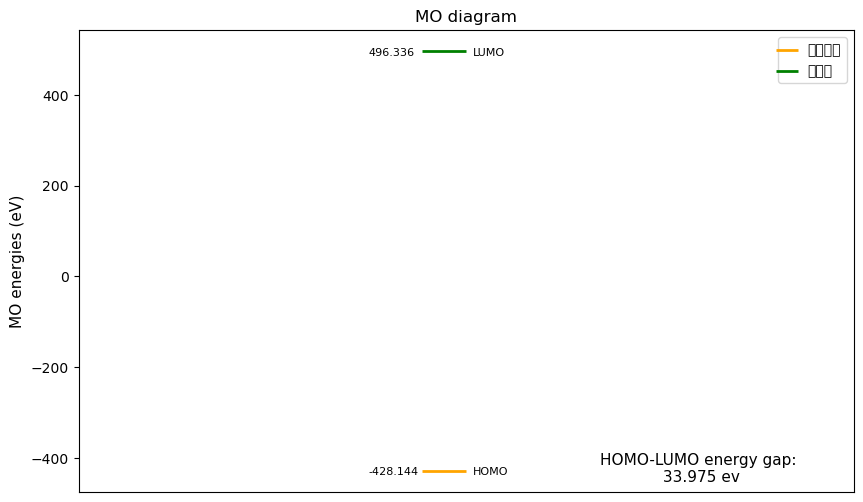

,エネルギー(eV),電子の数,種類
1,18.240,0,LUMO
0,-15.734,2,HOMO


In [51]:
assert 'mf' in globals(), 'Please run the above calculation first.'

def mo_diagram(mf):
    '''Displays MO energy level diagram.
    Args:
      mf (pyscf.scf.RHF or pyscf.scf.RKS): pyscf HF or DFT calculation object.
    '''
    # Find HOMO-LUMO gap
    homo_num  = np.count_nonzero(mf.mo_occ == 2) - 1
    lumo_num  = np.count_nonzero(mf.mo_occ == 2)
    homo_en   = mf.mo_energy[homo_num]
    mos_occ   = mf.mo_coeff[:,:lumo_num]
    lumo_en   = mf.mo_energy[lumo_num]
    mos_unocc = mf.mo_coeff[:,lumo_num:]
    hl_gap    = abs(lumo_en - homo_en)
    hl_gap_ev = hl_gap * 27.2114

    # Create a list MO labels
    MO_labels = []
    for i in range(len(mf.mo_occ)-lumo_num):
        if i == 0:
            MO_labels.append('LUMO')
        else:
            MO_labels.append(f'LUMO+{i}')
    MO_labels.reverse()
    for i in range(homo_num+1):
        if i == 0 :
            MO_labels.append('HOMO')
        else:
            MO_labels.append(f'HOMO-{i}')
    MO_labels.reverse()
    #print(MO_labels)

    table = pd.DataFrame({ "エネルギー(eV)": 27.2114 * mf.mo_energy, "電子の数": mf.mo_occ.astype('int'), "種類": MO_labels})
    table = table.round(decimals=3)
    #print(table)

    print(f'分子軌道の総数 = ', table.shape[0])
    print('最大8つ分子軌道のダイアグラムを作る ......')

    global frontier_nums, frontier_labels, frontier_energies

    homo_front_min    = homo_num if homo_num < 3 else homo_num - 3
    lumo_front_max    = table.shape[0] if lumo_num + 4 > table.shape[0] else lumo_num + 4
    frontier_nums     = np.arange(homo_front_min,lumo_front_max,1)
    frontier_labels   = table.iloc[frontier_nums]['種類'].tolist()
    frontier_energies = table.iloc[frontier_nums]['エネルギー(eV)'].tolist()

    y = np.around(np.array(frontier_energies)*27.2114,3) # orbital energy values
    x = [1] # orbital positions on the graph (useful for degenrated orbitals)
    for i in range(1,len(y)):
        if y[i] == y[i-1]:
          x.append(x[i-1]+0.3)
        else:
          x.append(1)

    # Building up the diagram
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.ylabel("MO energies (eV)", size=11)
    plt.scatter(x[:homo_num - homo_front_min + 1], y[:homo_num - homo_front_min + 1], marker=0, s=1000, linewidths=2, color='orange', label='被占軌道')
    plt.scatter(x[homo_num - homo_front_min + 1:], y[homo_num - homo_front_min + 1:], marker=0, s=1000, linewidths=2, color='green', label='空軌道')
    for xi, yi, labels in zip(x, y, frontier_labels):
        plt.annotate(labels, (xi, yi), size=8, xycoords='data', xytext=(5, -3), textcoords='offset points')
    for xi, yi, labels in zip(x, y, y):
        plt.annotate(labels, (xi, yi), size=8, xycoords='data', xytext=(-70, -3), textcoords='offset points')
    plt.rcParams["legend.markerscale"] = 0.50
    plt.legend(loc='upper right', handletextpad=-0.3)
    plt.title(f'MO diagram')
    plt.xticks([])

    plt.xlim([min(x) - 0.3, max(x) + 0.3])
    #plt.ylim([min(y) - 0.5, max(y) + 0.5])

    # display HOMO-LUMO gap value
    plt.text(0.8, 0.05, f'HOMO-LUMO energy gap:\n {hl_gap_ev:.3f} ev',
             horizontalalignment='center', verticalalignment='center',
             transform=ax.transAxes, size=11)
    plt.show()

    display(table.iloc[homo_front_min:lumo_front_max][::-1])

mo_diagram(mf)



## Generating cube files

In [52]:
# %%capture prevents output from displaying
%%capture cap --no-stderr

good_isovalues = [] # list of isovalues that render well in subsequent visualization

def get_orbital(i, label):
  '''Saves .cube files of orbital and prob. density from the above calculation.
  Args:
    i (int): Index to iterate over in for loop.
    label (str): MO label, i.e. HOMO, HOMO-1, etc.
  '''
  tools.cubegen.orbital(mol_quantum, f'{label}.cube', mf.mo_coeff[:,i],nx=80,ny=80,nz=80)

print(".cube ファイルの生成 (~1分　かかる) \u231B ...", end= "\n\n", file=sys.stderr)
# Generate .cube files for all orbitals in the above table
for i in range(len(frontier_nums)):
  get_orbital(frontier_nums[i],frontier_labels[i])
print("\033[1m終わり! \033[0m", end='\n\n', file=sys.stderr)

# save data to dictionary
grid_data = {}
for name in frontier_labels:
  with open(f'{name}.cube') as f:
    grid_data[f'{name}'] = f.read()

UsageError: Line magic function `%%capture` not found.


## Plot orbitals

In [20]:
orbital_select = widgets.Dropdown(value='HOMO',options=frontier_labels,description='分子軌道: ')

isoval_select = widgets.BoundedFloatText(
    value=0.04,
    min=0,
    max=1.0,
    step=0.01,
    description='アイソバリュー:',
    disabled=False,
    style={'description_width': 'initial'}
)

def draw_orbital(label, isoval, show_noninteractive_png=False):
  '''Renders isosurface of selected orbital from calculation.
  Args:
    label (str): Orbital designation, e.g. HOMO, HOMO-1, etc.
  '''
  view = py3Dmol.view(width=500,height=500)
  print('----------------------------------------')
  #print(f'isovalue: {isoval:.4f}')
  print('レンダリング中 (~30秒　かかる) \u231B ...')
  view.addVolumetricData(grid_data[f'{label}'], "cube", {'isoval': isoval, 'color': "red", 'opacity': 0.90})
  view.addVolumetricData(grid_data[f'{label}'], "cube", {'isoval': -isoval, 'color': "blue", 'opacity': 0.90})

  if molecule_name == 'Hydrogen dimer':
   view.addModel(h2, 'mol')
  else:
   view.addModel(Chem.MolToMolBlock(mol), 'mol')
  view.setStyle({'stick':{}, 'sphere': {"scale":0.3}})

  if show_noninteractive_png:
    view.zoomTo()
    view.show()
    view.png()
  else:
    view.zoomTo()
    view.show()

#display(Markdown(f'### {molecule_smiles[molecule_dropdown.value-1][1]} frontier MOs calculated at {calc_method}/{basis_sets[basis_dropdown.value-1][0]} level of theory'))
#print(" ")

widgets.interactive(draw_orbital, {'manual': True, "manual_name": "レンダリングする"}, label=orbital_select, isoval = isoval_select)

NameError: name 'output' is not defined

© 2025 Mariia IVONINA (Tada Lab. at Kyushu University, Q-PIT). 無断転載を禁じます。